# EDA: Multi-Task NEAT vs HA-NEAT (MJX Backend)

Analyses the `multi_task_neat_vs_haneat_mjx_backend` experiment.

**Key questions:**
1. Which aggregation mode (sum / min / product) leads to balanced Hopper + Walker2D learning?
2. Does HA-NEAT outperform NEAT?
3. How do population size and generation limit affect results?
4. Why do most runs show high variance / no convergence?

In [6]:
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from IPython.display import display
import os

# Point to the local MLflow database
DB_PATH = os.path.abspath(os.path.join(os.getcwd(), '..', 'mlflow.db'))
mlflow.set_tracking_uri(f'sqlite:///{DB_PATH}')

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
EXPERIMENT_NAME = 'multi_task_neat_vs_haneat_mjx_backend'
HOPPER_MAX   = 3000.0
WALKER_MAX   = 5000.0

AGG_ORDER  = ['normalized_sum', 'normalized_min', 'normalized_product']
AGG_COLORS = {'normalized_sum': '#1f77b4', 'normalized_min': '#2ca02c', 'normalized_product': '#d62728'}
ALG_STYLES = {'neat': '-', 'ha_neat': '--'}
HIGHLIGHT  = ['ha_neat_normalized_min_pop2048_gen200_seed123',
               'neat_normalized_product_pop1024_gen200_seed123']
print(f'Tracking URI: {mlflow.get_tracking_uri()}')
print('Setup done.')

Tracking URI: sqlite:////Users/svengoerdes/Projects/Thesisv2/tensorneat/mlflow.db
Setup done.


## 1. Load Data from MLflow

In [7]:
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name(EXPERIMENT_NAME)
runs_raw = client.search_runs(experiment_ids=[exp.experiment_id])

METRICS = ['fitness/max', 'fitness/mean', 'fitness/hopper', 'fitness/walker2d',
           'fitness_normalized/hopper', 'fitness_normalized/walker2d',
           'neat/n_species', 'neat/best_genome_n_nodes', 'neat/best_genome_n_conns']

runs_meta = []
histories = {}   # run_name -> {metric -> pd.Series(index=generation)}

for r in runs_raw:
    if r.info.status not in ('FINISHED', 'RUNNING'):
        continue
    p = r.data.params
    name = r.info.run_name
    runs_meta.append({
        'run_name':        name,
        'run_id':          r.info.run_id,
        'algorithm_type':  p.get('algorithm_type', '?'),
        'aggregation_mode':p.get('aggregation_mode', '?'),
        'pop_size':        int(p.get('pop_size', 0)),
        'generation_limit':int(p.get('generation_limit', 0)),
        'seed':            int(p.get('seed', 0)),
        'status':          r.info.status,
    })
    hist = {}
    for metric in METRICS:
        points = client.get_metric_history(r.info.run_id, metric)
        if points:
            hist[metric] = pd.Series({pt.step: pt.value for pt in points}, name=metric)
    histories[name] = hist

meta = pd.DataFrame(runs_meta).sort_values(['algorithm_type','aggregation_mode','pop_size','generation_limit'])
print(f'Loaded {len(meta)} runs')
display(meta[['run_name','algorithm_type','aggregation_mode','pop_size','generation_limit','status']])

Loaded 36 runs


,run_name,algorithm_type,aggregation_mode,pop_size,generation_limit,status
11,ha_neat_normalized_min_pop512_gen100_seed123,ha_neat,normalized_min,512,100,FINISHED
10,ha_neat_normalized_min_pop512_gen200_seed123,ha_neat,normalized_min,512,200,FINISHED
9,ha_neat_normalized_min_pop1024_gen100_seed123,ha_neat,normalized_min,1024,100,FINISHED
8,ha_neat_normalized_min_pop1024_gen200_seed123,ha_neat,normalized_min,1024,200,FINISHED
7,ha_neat_normalized_min_pop2048_gen100_seed123,ha_neat,normalized_min,2048,100,FINISHED
6,ha_neat_normalized_min_pop2048_gen200_seed123,ha_neat,normalized_min,2048,200,FINISHED
17,ha_neat_normalized_product_pop512_gen100_seed123,ha_neat,normalized_product,512,100,FINISHED
16,ha_neat_normalized_product_pop512_gen200_seed123,ha_neat,normalized_product,512,200,FINISHED
15,ha_neat_normalized_product_pop1024_gen100_seed123,ha_neat,normalized_product,1024,100,FINISHED
14,ha_neat_normalized_product_pop1024_gen200_seed123,ha_neat,normalized_product,1024,200,FINISHED


## 2. Final-Generation Summary Table

In [8]:
def last_val(run_name, metric):
    h = histories.get(run_name, {}).get(metric)
    return float(h.iloc[-1]) if h is not None and len(h) > 0 else np.nan

summary = meta.copy()
for col, metric in [('hopper_final',  'fitness/hopper'),
                     ('walker_final',  'fitness/walker2d'),
                     ('hop_norm',      'fitness_normalized/hopper'),
                     ('wal_norm',      'fitness_normalized/walker2d'),
                     ('fitness_max',   'fitness/max')]:
    summary[col] = summary['run_name'].apply(lambda n: last_val(n, metric))

display(summary[['algorithm_type','aggregation_mode','pop_size','generation_limit',
                  'hopper_final','walker_final','hop_norm','wal_norm','fitness_max']]
        .style.format({'hopper_final':'{:.0f}','walker_final':'{:.0f}',
                       'hop_norm':'{:.3f}','wal_norm':'{:.3f}','fitness_max':'{:.4f}'})
        .background_gradient(subset=['walker_final'], cmap='RdYlGn')
        .background_gradient(subset=['hopper_final'], cmap='RdYlGn'))

,algorithm_type,aggregation_mode,pop_size,generation_limit,hopper_final,walker_final,hop_norm,wal_norm,fitness_max
11,ha_neat,normalized_min,512,100,1049,1476,0.350,0.295,0.3269
10,ha_neat,normalized_min,512,200,1028,1813,0.343,0.363,0.3427
9,ha_neat,normalized_min,1024,100,1058,491,0.353,0.098,0.3507
8,ha_neat,normalized_min,1024,200,1158,1827,0.386,0.365,0.3768
7,ha_neat,normalized_min,2048,100,1106,1611,0.369,0.322,0.3635
6,ha_neat,normalized_min,2048,200,1182,2012,0.394,0.402,0.3946
17,ha_neat,normalized_product,512,100,1046,1190,0.349,0.238,0.1043
16,ha_neat,normalized_product,512,200,1030,214,0.343,0.043,0.1306
15,ha_neat,normalized_product,1024,100,1022,1592,0.341,0.318,0.1198
14,ha_neat,normalized_product,1024,200,1008,66,0.336,0.013,0.1342


## 3. Aggregation Mode Comparison

Per-task fitness over generations — does `min` / `product` actually force Walker2D to improve?

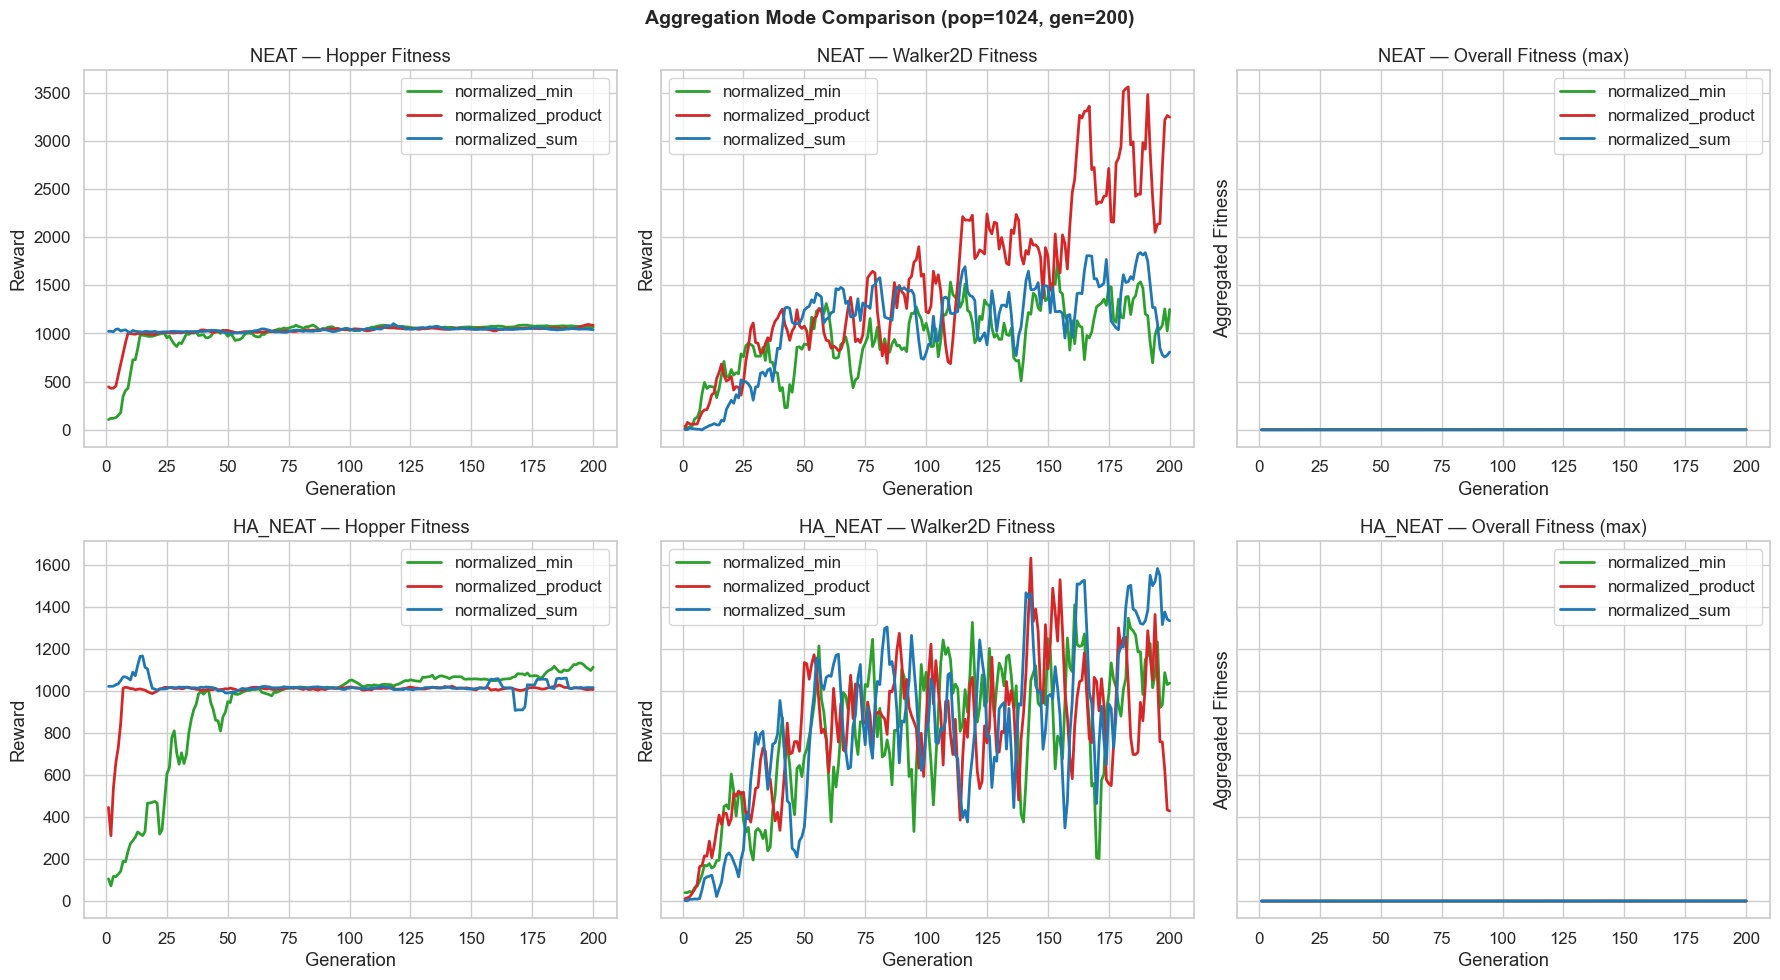

In [9]:
def plot_metric_by_agg(algorithm, metric, ylabel, title, ax, smooth=5):
    subset = meta[(meta['algorithm_type'] == algorithm) & (meta['pop_size'] == 1024) & (meta['generation_limit'] == 200)]
    for _, row in subset.iterrows():
        agg = row['aggregation_mode']
        h = histories.get(row['run_name'], {}).get(metric)
        if h is None: continue
        s = h.rolling(smooth, min_periods=1).mean()
        ax.plot(s.index, s.values, label=agg, color=AGG_COLORS.get(agg), linewidth=2)
    ax.set_title(f'{algorithm.upper()} — {title}')
    ax.set_xlabel('Generation')
    ax.set_ylabel(ylabel)
    ax.legend()

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey='row')
for col, (metric, ylabel, title) in enumerate([
    ('fitness/hopper',  'Reward', 'Hopper Fitness'),
    ('fitness/walker2d','Reward', 'Walker2D Fitness'),
    ('fitness/max',     'Aggregated Fitness', 'Overall Fitness (max)'),
]):
    plot_metric_by_agg('neat',   metric, ylabel, title, axes[0, col])
    plot_metric_by_agg('ha_neat',metric, ylabel, title, axes[1, col])

fig.suptitle('Aggregation Mode Comparison (pop=1024, gen=200)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. NEAT vs HA-NEAT

Does HA-NEAT's activation diversity help with multi-task performance?

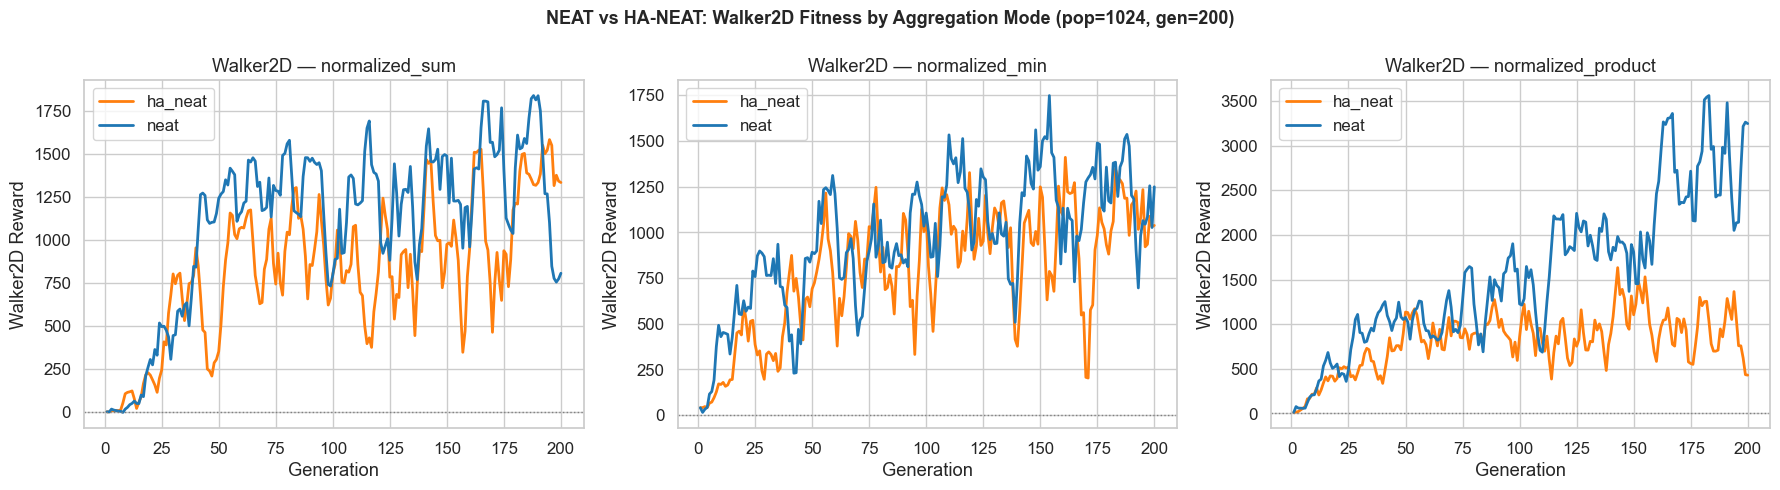

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
alg_colors = {'neat': '#1f77b4', 'ha_neat': '#ff7f0e'}

for ax, agg in zip(axes, AGG_ORDER):
    subset = meta[(meta['aggregation_mode'] == agg) & (meta['pop_size'] == 1024) & (meta['generation_limit'] == 200)]
    for _, row in subset.iterrows():
        alg = row['algorithm_type']
        h = histories.get(row['run_name'], {}).get('fitness/walker2d')
        if h is None: continue
        s = h.rolling(5, min_periods=1).mean()
        ax.plot(s.index, s.values, label=alg, color=alg_colors[alg], linewidth=2)
    ax.set_title(f'Walker2D — {agg}')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Walker2D Reward')
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.legend()

fig.suptitle('NEAT vs HA-NEAT: Walker2D Fitness by Aggregation Mode (pop=1024, gen=200)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Population & Generation Heatmaps

Final Walker2D normalized fitness across all configurations.

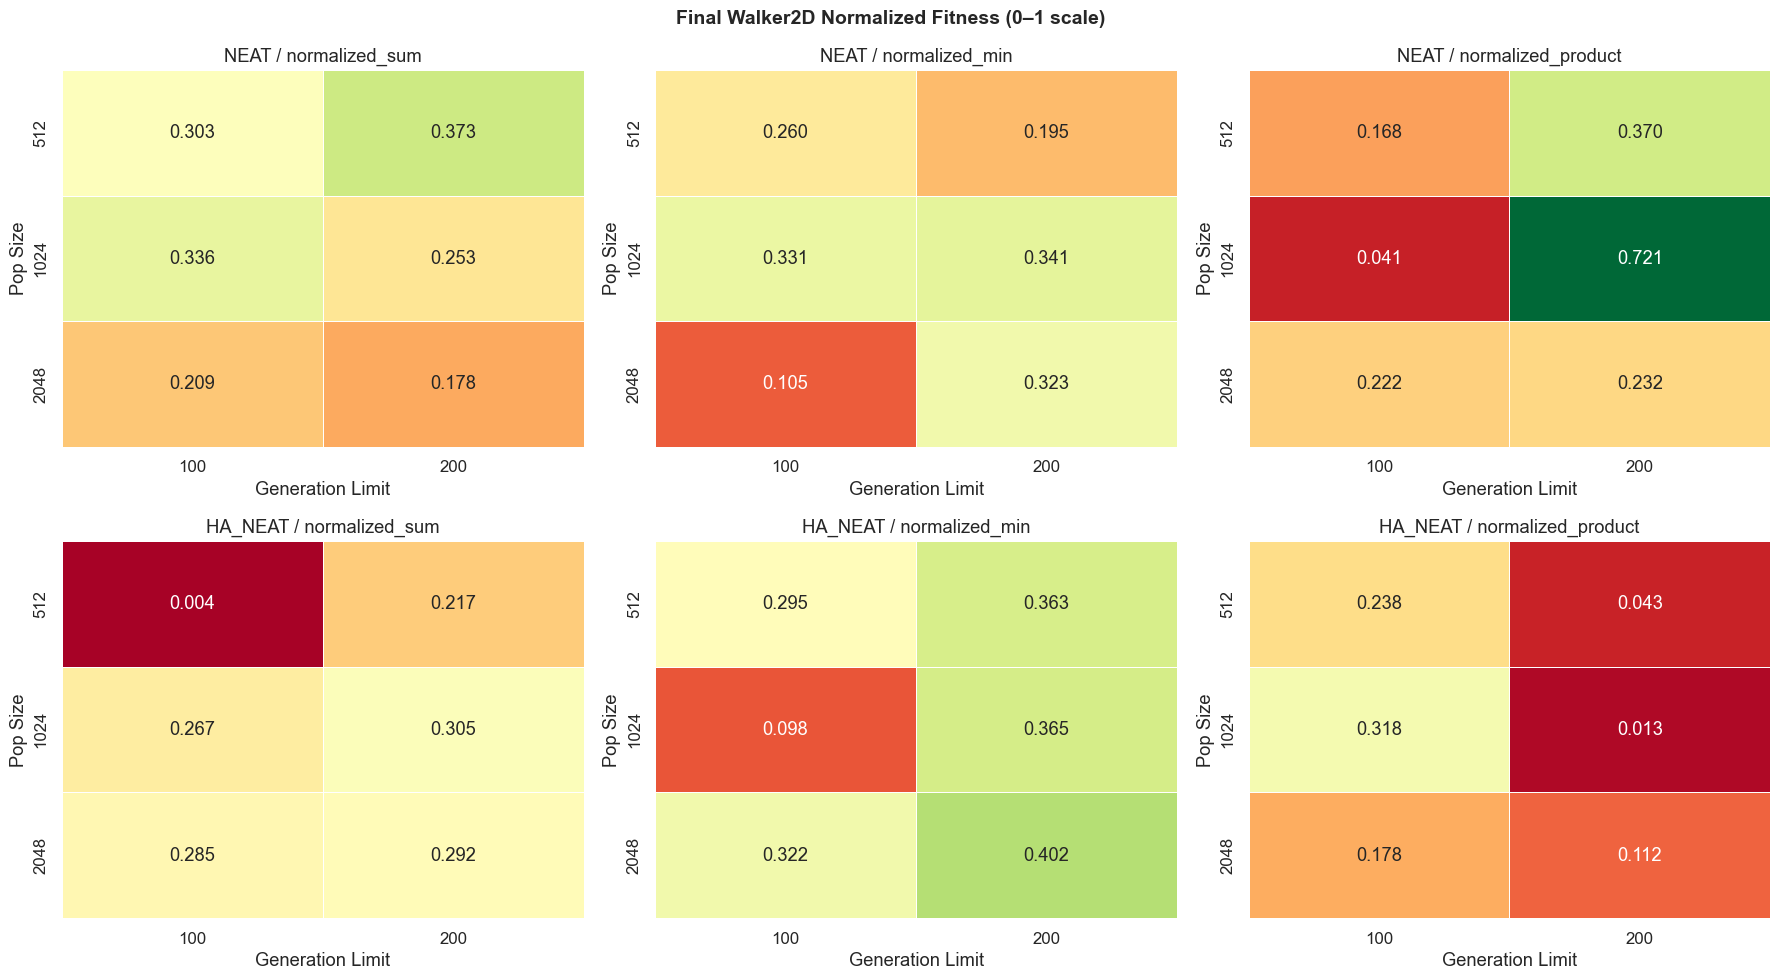

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row_idx, alg in enumerate(['neat', 'ha_neat']):
    for col_idx, agg in enumerate(AGG_ORDER):
        ax = axes[row_idx, col_idx]
        subset = summary[(summary['algorithm_type'] == alg) & (summary['aggregation_mode'] == agg)]
        pivot = subset.pivot_table(index='pop_size', columns='generation_limit', values='wal_norm')
        sns.heatmap(pivot, ax=ax, annot=True, fmt='.3f', cmap='RdYlGn',
                    vmin=0, vmax=0.6, linewidths=0.5, cbar=False)
        ax.set_title(f'{alg.upper()} / {agg}')
        ax.set_xlabel('Generation Limit')
        ax.set_ylabel('Pop Size')

fig.suptitle('Final Walker2D Normalized Fitness (0–1 scale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Highlighted Runs: Stability Analysis

**`ha_neat_normalized_min_pop2048_gen200`** — stable Walker2D after gen ~100  
**`neat_normalized_product_pop1024_gen200`** — highest Walker2D max reward

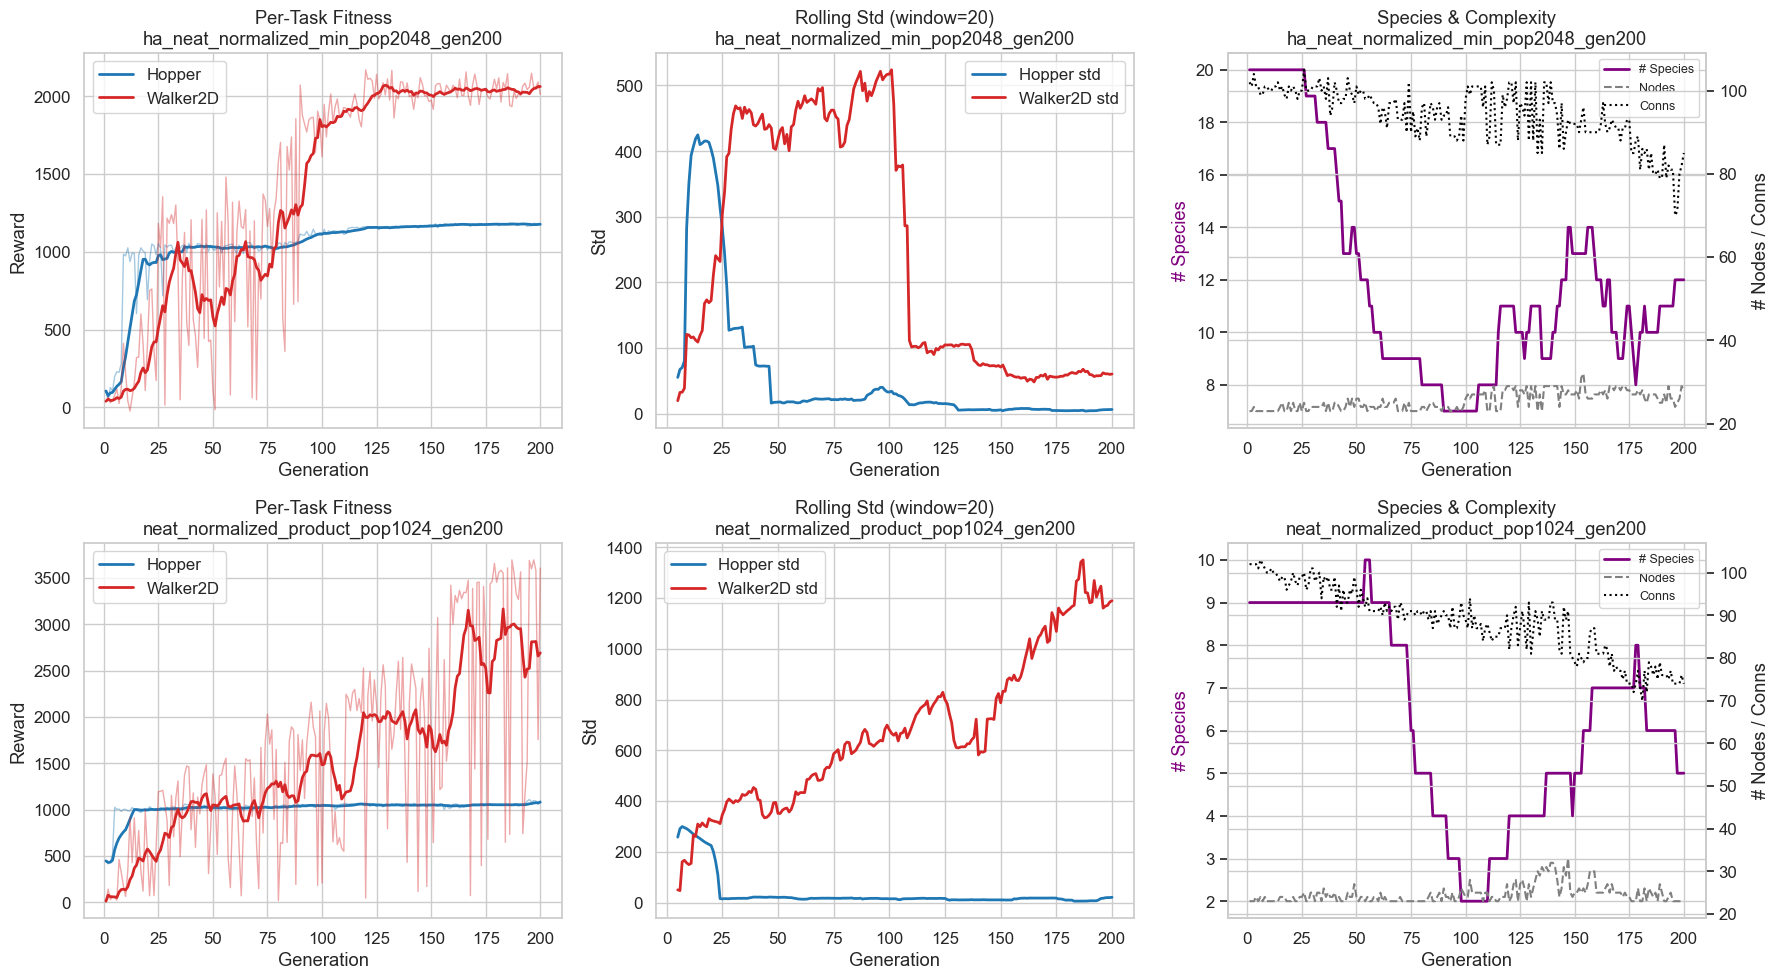

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row_idx, run_name in enumerate(HIGHLIGHT):
    hist = histories.get(run_name, {})
    label = run_name.replace('_seed123', '')

    # Hopper + Walker2D raw fitness
    ax = axes[row_idx, 0]
    for metric, color, lbl in [
        ('fitness/hopper',  '#1f77b4', 'Hopper'),
        ('fitness/walker2d','#d62728', 'Walker2D'),
    ]:
        h = hist.get(metric)
        if h is not None:
            ax.plot(h.index, h.values, color=color, alpha=0.4, linewidth=1)
            ax.plot(h.index, h.rolling(10, min_periods=1).mean(), color=color, linewidth=2, label=lbl)
    ax.set_title(f'Per-Task Fitness\n{label}')
    ax.set_xlabel('Generation'); ax.set_ylabel('Reward')
    ax.legend()

    # Rolling std (variability)
    ax = axes[row_idx, 1]
    for metric, color, lbl in [
        ('fitness/hopper',  '#1f77b4', 'Hopper std'),
        ('fitness/walker2d','#d62728', 'Walker2D std'),
    ]:
        h = hist.get(metric)
        if h is not None:
            std = h.rolling(20, min_periods=5).std()
            ax.plot(std.index, std.values, color=color, linewidth=2, label=lbl)
    ax.set_title(f'Rolling Std (window=20)\n{label}')
    ax.set_xlabel('Generation'); ax.set_ylabel('Std')
    ax.legend()

    # NEAT structural metrics
    ax = axes[row_idx, 2]
    ax2 = ax.twinx()
    h_sp = hist.get('neat/n_species')
    h_no = hist.get('neat/best_genome_n_nodes')
    h_co = hist.get('neat/best_genome_n_conns')
    if h_sp is not None:
        ax.plot(h_sp.index, h_sp.values, color='purple', linewidth=2, label='# Species')
    if h_no is not None:
        ax2.plot(h_no.index, h_no.values, color='gray', linestyle='--', linewidth=1.5, label='Nodes')
    if h_co is not None:
        ax2.plot(h_co.index, h_co.values, color='black', linestyle=':', linewidth=1.5, label='Conns')
    ax.set_title(f'Species & Complexity\n{label}')
    ax.set_xlabel('Generation')
    ax.set_ylabel('# Species', color='purple')
    ax2.set_ylabel('# Nodes / Conns')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=9)

plt.tight_layout()
plt.show()

## 7. Variability Analysis

Why do most runs show high variance and no convergence?  
Compare rolling std across all runs, grouped by aggregation mode.

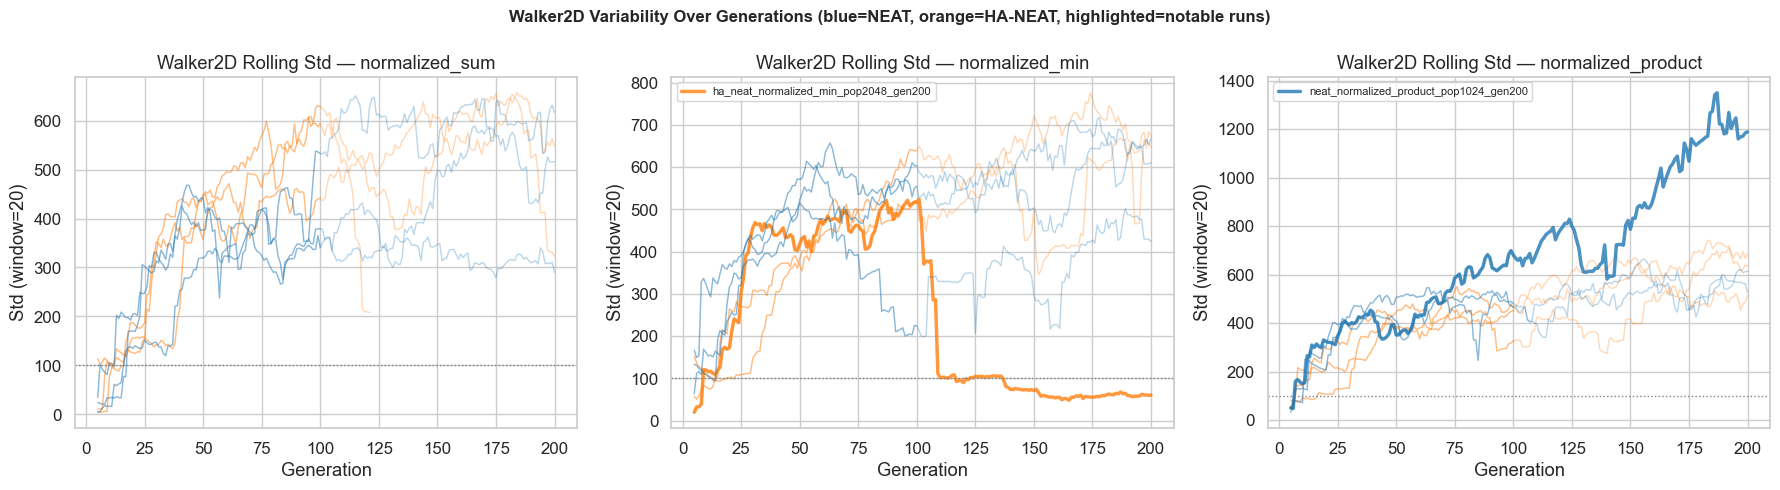

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, agg in zip(axes, AGG_ORDER):
    subset = meta[meta['aggregation_mode'] == agg]
    for _, row in subset.iterrows():
        h = histories.get(row['run_name'], {}).get('fitness/walker2d')
        if h is None or len(h) < 20: continue
        std = h.rolling(20, min_periods=5).std()
        alg = row['algorithm_type']
        color = '#1f77b4' if alg == 'neat' else '#ff7f0e'
        alpha = 0.8 if row['run_name'] in HIGHLIGHT else 0.3
        lw    = 2.5 if row['run_name'] in HIGHLIGHT else 1
        label = row['run_name'].replace('_seed123','') if row['run_name'] in HIGHLIGHT else None
        ax.plot(std.index, std.values, color=color, alpha=alpha, linewidth=lw, label=label)
    ax.set_title(f'Walker2D Rolling Std — {agg}')
    ax.set_xlabel('Generation')
    ax.set_ylabel('Std (window=20)')
    if any(row['run_name'] in HIGHLIGHT for _, row in subset.iterrows()):
        ax.legend(fontsize=8)
    # Add reference lines
    ax.axhline(100, color='gray', linestyle=':', linewidth=1, label='100 reward std')

fig.suptitle('Walker2D Variability Over Generations (blue=NEAT, orange=HA-NEAT, highlighted=notable runs)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Best Runs Summary

Top 10 runs by final Walker2D normalized fitness.

In [14]:
top = summary.nlargest(10, 'wal_norm')[[
    'run_name','algorithm_type','aggregation_mode','pop_size','generation_limit',
    'hopper_final','walker_final','hop_norm','wal_norm'
]]
display(top.style
    .format({'hopper_final':'{:.0f}','walker_final':'{:.0f}','hop_norm':'{:.3f}','wal_norm':'{:.3f}'})
    .background_gradient(subset=['wal_norm','hop_norm'], cmap='RdYlGn')
    .set_caption('Top 10 runs by final Walker2D normalized fitness'))

print('\n--- Key Observations ---')
for name in HIGHLIGHT:
    row = summary[summary['run_name'] == name].iloc[0]
    print(f"  {name}")
    print(f"    Hopper:  {row['hopper_final']:.0f} ({row['hop_norm']:.3f} norm)")
    print(f"    Walker2D:{row['walker_final']:.0f} ({row['wal_norm']:.3f} norm)")

,run_name,algorithm_type,aggregation_mode,pop_size,generation_limit,hopper_final,walker_final,hop_norm,wal_norm
32,neat_normalized_product_pop1024_gen200_seed123,neat,normalized_product,1024,200,1096,3606,0.365,0.721
6,ha_neat_normalized_min_pop2048_gen200_seed123,ha_neat,normalized_min,2048,200,1182,2012,0.394,0.402
22,neat_normalized_sum_pop512_gen200_seed123,neat,normalized_sum,512,200,1075,1866,0.358,0.373
34,neat_normalized_product_pop512_gen200_seed123,neat,normalized_product,512,200,1047,1849,0.349,0.370
8,ha_neat_normalized_min_pop1024_gen200_seed123,ha_neat,normalized_min,1024,200,1158,1827,0.386,0.365
10,ha_neat_normalized_min_pop512_gen200_seed123,ha_neat,normalized_min,512,200,1028,1813,0.343,0.363
26,neat_normalized_min_pop1024_gen200_seed123,neat,normalized_min,1024,200,1078,1706,0.359,0.341
21,neat_normalized_sum_pop1024_gen100_seed123,neat,normalized_sum,1024,100,1021,1679,0.340,0.336
27,neat_normalized_min_pop1024_gen100_seed123,neat,normalized_min,1024,100,1016,1655,0.339,0.331
24,neat_normalized_min_pop2048_gen200_seed123,neat,normalized_min,2048,200,1039,1615,0.346,0.323



--- Key Observations ---
  ha_neat_normalized_min_pop2048_gen200_seed123
    Hopper:  1182 (0.394 norm)
    Walker2D:2012 (0.402 norm)
  neat_normalized_product_pop1024_gen200_seed123
    Hopper:  1096 (0.365 norm)
    Walker2D:3606 (0.721 norm)
